<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/08_priority_naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
## Notebook 08 Naive Bayes Classifier (Priority Prediction)

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook builds a baseline Naive Bayes classifier to predict request priority (HIGH/MEDIUM/LOW) from the request text. Unlike department classification, priority is not directly encoded in the category taxonomy, making this a genuinely harder prediction task.

## Mounting Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the processed data

We use the same request text (X) as department classification, but the priority labels (y) instead.

In [4]:
processed_dir = '/content/drive/MyDrive/council-classifier/processed'

X_train = np.load(f'{processed_dir}/X_train.npy', allow_pickle=True)
X_test = np.load(f'{processed_dir}/X_test.npy', allow_pickle=True)
y_prio_train = np.load(f'{processed_dir}/y_prio_train.npy', allow_pickle=True)
y_prio_test = np.load(f'{processed_dir}/y_prio_test.npy', allow_pickle=True)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))
print("\nPriority distribution in training set:")
print(pd.Series(y_prio_train).value_counts(normalize=True) * 100)

Training set size: 203501
Test set size: 50876

Priority distribution in training set:
LOW       47.311807
MEDIUM    27.123208
HIGH      25.564985
Name: proportion, dtype: float64


## Building a pipeline combining vectorisation and classification

We bundle the CountVectorizer and MultinomialNB classifier into a single pipeline. This avoids train/serve mismatch and simplifies saving and loading the model later for the dashboard.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

priority_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(max_features=1500)),
    ('classifier', MultinomialNB())
])

priority_pipeline.fit(X_train, y_prio_train)

Pipeline(steps=[('vectorizer', CountVectorizer(max_features=1500)),
                ('classifier', MultinomialNB())])

## Predicting the Test set results

In [6]:
y_pred = priority_pipeline.predict(X_test)

print("Sample predictions vs actual:")
comparison = pd.DataFrame({'Predicted': y_pred[:15], 'Actual': y_prio_test[:15]})
print(comparison)

Sample predictions vs actual:
   Predicted  Actual
0     MEDIUM  MEDIUM
1       HIGH    HIGH
2     MEDIUM  MEDIUM
3       HIGH    HIGH
4        LOW     LOW
5       HIGH    HIGH
6        LOW     LOW
7     MEDIUM  MEDIUM
8       HIGH    HIGH
9     MEDIUM  MEDIUM
10    MEDIUM  MEDIUM
11       LOW     LOW
12       LOW    HIGH
13    MEDIUM  MEDIUM
14    MEDIUM    HIGH


## Making the Confusion Matrix

This will be a 3x3 matrix since there are three priority classes: HIGH, MEDIUM, LOW.

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_prio_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y_prio_test, y_pred))

Confusion Matrix:
[[ 4438  2015  6564]
 [ 1317 17541  5191]
 [ 1563  2286  9961]]

Accuracy: 0.627800927745892


## Classification Report

In [8]:
print(classification_report(y_prio_test, y_pred))

              precision    recall  f1-score   support

        HIGH       0.61      0.34      0.44     13017
         LOW       0.80      0.73      0.76     24049
      MEDIUM       0.46      0.72      0.56     13810

    accuracy                           0.63     50876
   macro avg       0.62      0.60      0.59     50876
weighted avg       0.66      0.63      0.63     50876



## Visualising the Confusion Matrix


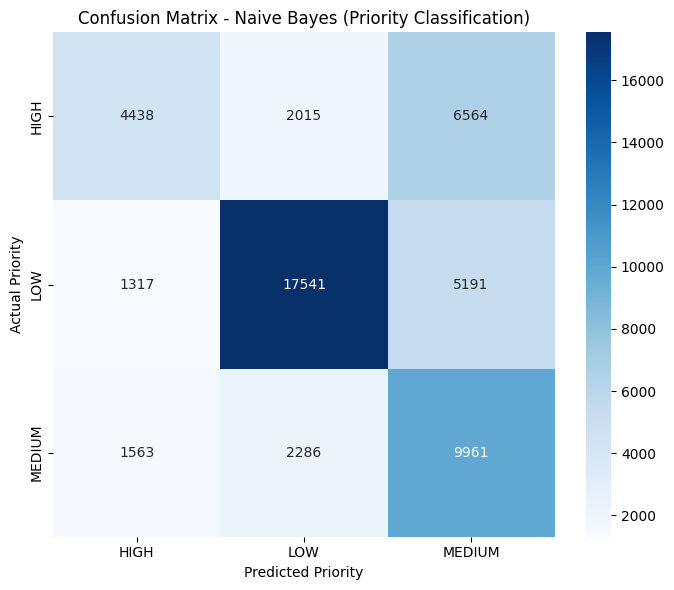

In [9]:
plt.figure(figsize=(7, 6))
unique_labels = sorted(set(y_prio_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix - Naive Bayes (Priority Classification)')
plt.xlabel('Predicted Priority')
plt.ylabel('Actual Priority')
plt.tight_layout()
plt.show()

## Saving the baseline priority results

Starting a new results file specifically for priority prediction, kept separate from the department classification comparison.

In [11]:
from sklearn.metrics import f1_score

results = {
    'model': 'Naive Bayes',
    'accuracy': accuracy_score(y_prio_test, y_pred),
    'f1_macro': f1_score(y_prio_test, y_pred, average='macro'),
    'f1_weighted': f1_score(y_prio_test, y_pred, average='weighted')
}

print(results)

results_df = pd.DataFrame([results])
results_path = '/content/drive/MyDrive/council-classifier/processed/priority_model_results.csv'
results_df.to_csv(results_path, index=False)
print("\nResults saved to:", results_path)

{'model': 'Naive Bayes', 'accuracy': 0.627800927745892, 'f1_macro': 0.5872416082536761, 'f1_weighted': 0.6252580236291303}

Results saved to: /content/drive/MyDrive/council-classifier/processed/priority_model_results.csv
